# Reddit Data Analysis & Score Prediction

This notebook analyzes Reddit posts from r/askscience to predict post scores using NLP techniques and machine learning.

Objective:
- Determine the attributes of a successful post on r/askscience
- Build a model that can predict the score of a post on r/askscience given at least the title and body of the post (There is no need to limit it to just the title and body, but you must explain why you chose the features you did).

Approach:
- Data Loading & EDA : In these steps, I'm trying to understand different features in the dataset and perform EDA to understand which features have an impct on the score. Helps in understanding what is successful post with good score.
- Feature Selection and Engineering - Identifyinf features that are significant in determing the success of a post with great score.
- Model building and Training - Building a regressor model to predict scores based on the features identified in Feature engineering and selection. Initially used a Linear regression as a baseline model and later on progressed to complex models.

Note: The explainations for the features during the EDA, Feature Engineering and Selection are in the analysis.ipynb file in the same folder. This summary notebook has the high level overview for score predictions.

## Data Loading & Cleaning

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from scipy.stats import f_oneway
from sklearn.feature_extraction.text import TfidfVectorizer
import re
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load dataset
data = pd.read_csv('C:/Users/Sravya Ventrapragada/Documents/pls/takehome_sravya/askscience_data.csv')
data.drop('Unnamed: 0', axis=1, inplace=True)
data['datetime'] = pd.to_datetime(data['datetime'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4205 entries, 0 to 4204
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   title         4205 non-null   object        
 1   body          2492 non-null   object        
 2   tag           4011 non-null   object        
 3   datetime      4205 non-null   datetime64[ns]
 4   author        4205 non-null   object        
 5   score         4205 non-null   float64       
 6   upvote_ratio  4205 non-null   float64       
 7   url           4205 non-null   object        
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 262.9+ KB


## Exploratory Data Analysis (EDA)

In [14]:
# Check missing values
print(data.isnull().sum())

# Check duplicates
print(f'Duplicate Rows: {data.duplicated().sum()}')
# Drop duplicates - None found
data = data.drop_duplicates()

title              0
body            1713
tag              194
datetime           0
author             0
score              0
upvote_ratio       0
url                0
dtype: int64
Duplicate Rows: 36


## Feature Engineering

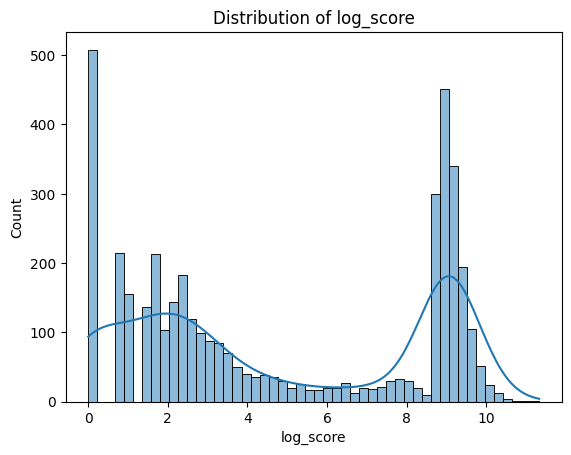

In [15]:
# Since the scores data is skewed, applying log-transform to the column
data["log_score"] = np.log1p(data['score'])  # log1p avoids log(0) issues

sns.histplot(data['log_score'], bins=50, kde=True)
plt.title("Distribution of log_score")
plt.show()

This plot indicates big spike at log_score = 0, which means many posts have a very less score. The next peak between 8-10 indicates the posts that 
went viral which might have received lot of upvotes. Now with the log tranform the spread is more even and easier to analyze. This also suggest a 
binomial distribution one group which has no engagement/upvotes(low log_score/unsuccessful) and other significant engagement(high log_score, succesful)

From the plots based on the elbow method, we can see a natural break in data  log_score between 5-7. So setting log_score cutoff at 6.

Low engagement: log_score < 6
High engagement: log_score ≥ 6
Based on set cutoff dividing the data and understand the word cloud of title.

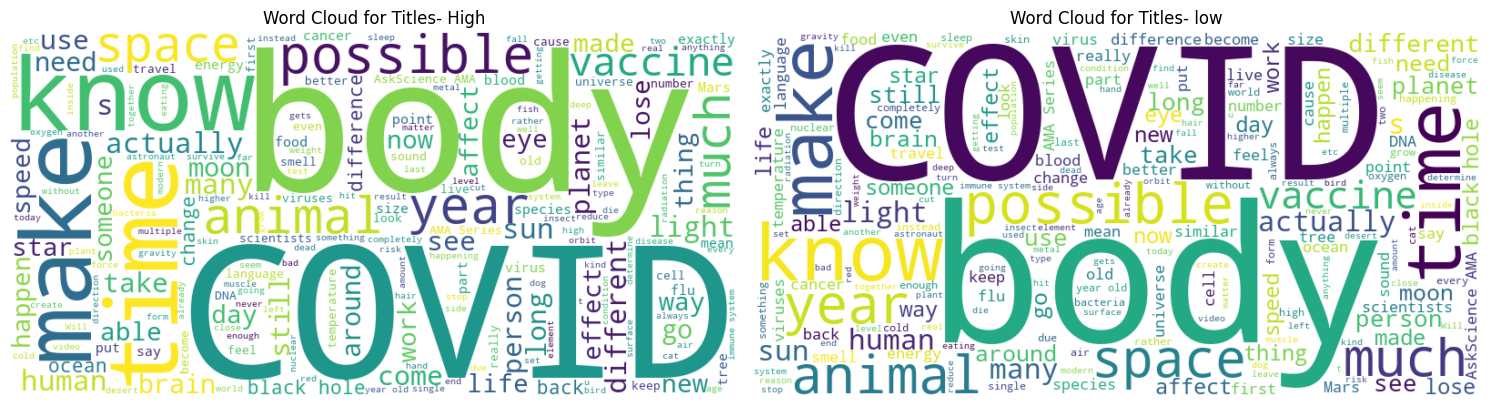

In [16]:
# Create high and low engagement data subset

data['title_modified'] = data['title'].fillna("")
data['body_modified'] = data['body'].fillna("")

threshold = 1000
high_engagement = data[data['score'] >= threshold]
low_engagement = data[data['score'] < threshold]

high_title_text = " ".join(high_engagement['title_modified'])
low_title_text = " ".join(low_engagement['title_modified'])

high_body_text = " ".join(high_engagement['body_modified'])
low_body_text = " ".join(low_engagement['body_modified'])


# Function to generate and display a word cloud
def plot_wordcloud(text1, text2, title):
    wordcloud1 = WordCloud(width=800, height=400, background_color='white', colormap='viridis', max_words=200).generate(text1)
    wordcloud2 = WordCloud(width=800, height=400, background_color='white', colormap='viridis', max_words=200).generate(text2)
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    axes[0].imshow(wordcloud1, interpolation="bilinear")
    axes[0].axis("off")
    axes[0].set_title(title + '- High')

    axes[1].imshow(wordcloud2, interpolation="bilinear")
    axes[1].axis("off")
    axes[1].set_title(title + '- low')
    plt.tight_layout()
    plt.show() 

# plot_wordcloud(high_title_text, low_title_text, "Word Cloud for Titles")

# plot_wordcloud(high_body_text, low_body_text, "Word Cloud for Body")

# Removing some of the most frequent words from titles to understand if there are any other significant titles.
words_to_remove = ['one', 'human', 'earth', 'Earth', 'water', 'people','will']
pattern = r'\b(?:' + '|'.join(map(re.escape, words_to_remove)) + r')\b'
high_cleaned_title_text = re.sub(pattern, '', high_title_text)
high_cleaned_title_text = ' '.join(high_cleaned_title_text.split())

low_cleaned_title_text = re.sub(pattern, '', high_title_text)
low_cleaned_title_text = ' '.join(low_cleaned_title_text.split())

plot_wordcloud(high_cleaned_title_text, low_cleaned_title_text, "Word Cloud for Titles")

From the word clouds we can see that the most frequent words in titles are present in both the categories. In general based on titles, we can say that there lots of posts related to earth, covid, human, water, time.

Whereas in body column, posts which have any links included(http) has gained lot of traction and inturn high scores. Similarly, posts which have questions, edits, and thank you have also gained lot traction because of continous interaction with updates on posts based on comments. 

From the table, we can see that there are null values in body and tag. This means these are the posts that have only title. Check how the null values are impacting the scores they are are useful as some people only write posts with title. 
Rows with Null values in body almost represent 40% of the data. These rows are posts with only title and should not be removed/ignored during analysis.

Detailed explanation for all the features that I considered for model training and prediction is in the analysis.ipynb file.

In [17]:
data['have_body'] = data['body'].apply(lambda x: 'yes' if pd.notnull(x) else 'no')
# Adding title length and body length
data['title_length'] = [len(x) for x in data["title"]]
data['body_length'] = [len(x) if pd.notnull(x) else 0 for x in data["body"]]
# Replacing author with author_post_count
author_counts = data['author'].value_counts()
author_counts = pd.DataFrame(author_counts)
author_counts.loc[author_counts['count'] > 6, 'count'] = 0
data['author_post_count'] = data['author'].replace(author_counts.index, author_counts['count'])
# Tags column information
tag_describe = data.groupby('tag')['score'].describe()
tag_describe.sort_values('count', ascending=False)
tags_to_combine = tag_describe[tag_describe['count'] < 10].index
data['tag'] = data['tag'].replace(tags_to_combine, 'Other')

# Understand the datetime column
data['hour'] = data['datetime'].dt.hour
data['dayofweek'] = data['datetime'].dt.dayofweek  # Monday=0, Sunday=6
data['month'] = data['datetime'].dt.month

# Title and body sentiment
analyzer = SentimentIntensityAnalyzer()
data['title_sentiment'] = data['title'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])
data['body_sentiment'] = data['body'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])
def sentiment_category(score):
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

# Apply categorization to title and body sentiment
data['title_sentiment_category'] = data['title_sentiment'].apply(sentiment_category)
data['body_sentiment_category'] = data['body_sentiment'].apply(sentiment_category)

# Title content transformation -Text Processing with TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(data['title'])

# Create "topic" reference documents based on frequency counts from above
science_doc = "billion years old light years away international space station supermassive black holes"
covid_doc = "covid 19 vaccine rate covid 19 water germs organisms human"
random_doc = "random number generator long period time"

# Transform topic documents
science_vec = vectorizer.transform([science_doc])
covid_vec = vectorizer.transform([covid_doc])
random_vec = vectorizer.transform([random_doc])

# Compute cosine similarity
data['science_similarity'] = cosine_similarity(tfidf_matrix, science_vec).flatten()
data['covid_similarity'] = cosine_similarity(tfidf_matrix, covid_vec).flatten()
data['random_similarity'] = cosine_similarity(tfidf_matrix, random_vec).flatten()

C:\Users\Sravya Ventrapragada\AppData\Local\Temp\ipykernel_15616\1376383664.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['author_post_count'] = data['author'].replace(author_counts.index, author_counts['count'])


## Model Training & Evaluation

Initially starting with linear regression as baseline model later on moving to complex algorithms like Random Forest Regressor and XGBoost Regressor.
Target is to predict the log_score value, Using MSE as evaluation metric.

Drop Unnecessary Columns - ['title', 'body', 'url', 'author', 'datetime','month', 'dayofweek']

features = [
    'upvote_ratio', 'title_length', 'body_length', 'author_post_count', 'hour', 'month',
    'title_sentiment', 'body_sentiment', 'science_similarity', 'covid_similarity', 'random_similarity',
    'have_body'
]
target = 'log_score' 

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# Drop Unnecessary Columns not used in X_train
drop_col = ['title', 'body', 'url', 'author', 'datetime','month', 'dayofweek', 'title_modified', 'body_modified', 'log_score', 'author', 'score']

features = [
    'upvote_ratio', 'title_length', 'body_length', 'author_post_count', 'hour', 'month',
    'title_sentiment', 'body_sentiment', 'science_similarity', 'covid_similarity', 'random_similarity',
    'have_body'
]
target = 'log_score' 

# Handling any missing values
print(data.shape)
data = data.dropna(subset=[target])  # Drop rows where score is missing
data[features] = data[features].fillna(0)  # Fill missing feature values with 0 - but no missing values

# Categorical Features - dummy values
data = pd.get_dummies(data, columns=['tag', 'title_sentiment_category', 'body_sentiment_category'], drop_first=True)
data['have_body'] = data['have_body'].map({'yes': 1, 'no': 0})

# Updated features with all the columns needed for training
updated_features = [col for col in data.columns.to_list() if col not in drop_col]
data[updated_features].columns

(4169, 25)


Index(['upvote_ratio', 'have_body', 'title_length', 'body_length',
       'author_post_count', 'hour', 'title_sentiment', 'body_sentiment',
       'science_similarity', 'covid_similarity', 'random_similarity',
       'tag_Archaeology', 'tag_Astronomy', 'tag_Biology', 'tag_COVID-19',
       'tag_Chemistry', 'tag_Computing', 'tag_Earth Sciences', 'tag_Economics',
       'tag_Engineering', 'tag_Human Body', 'tag_Linguistics',
       'tag_Mathematics', 'tag_Medicine', 'tag_Neuroscience', 'tag_Other',
       'tag_Paleontology', 'tag_Physics', 'tag_Planetary Sci.',
       'tag_Psychology', 'tag_Social Science',
       'title_sentiment_category_Neutral', 'title_sentiment_category_Positive',
       'body_sentiment_category_Neutral', 'body_sentiment_category_Positive'],
      dtype='object')

In [19]:
# Test Train split
X_train, X_test, y_train, y_test = train_test_split(data[updated_features], data[target], test_size=0.2, random_state=42)

In [20]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression - MAE: {mae_lr}, RMSE: {rmse_lr}, R²: {r2_lr}")

Linear Regression - MAE: 1.3893647799710065, RMSE: 1.8456864618517907, R²: 0.7430410220954348


In [21]:
# Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2_rf = r2_score(y_test, y_pred_lr)
print(f"Random Forest - MAE: {mae_rf}, RMSE: {rmse_rf}, R²: {r2_rf}")


# XGBoost Model
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = mean_squared_error(y_test, y_pred_xgb) ** 0.5
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost - MAE: {mae_xgb}, RMSE: {rmse_xgb}, R²: {r2_xgb}")

Random Forest - MAE: 0.8422850973647632, RMSE: 1.4405802792072036, R²: 0.7430410220954348
XGBoost - MAE: 0.8639401586866011, RMSE: 1.4131297727140069, R²: 0.84936980589175


Finding the best parameters using GridsearchCV

In [22]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

grid = GridSearchCV(xgb.XGBRegressor(random_state=42), param_grid, scoring='neg_mean_absolute_error', cv=3)
grid.fit(X_train, y_train)

print(f"Best Params: {grid.best_params_}")

# Use the best parameters found by GridSearchCV
best_model = grid.best_estimator_

# Fit the best model
best_model.fit(X_train, y_train)

# Make predictions
y_pred_best = best_model.predict(X_test)

# Evaluate the model
mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = mean_squared_error(y_test, y_pred_best) ** 0.5
r2_best = r2_score(y_test, y_pred_best)

# Print the evaluation metrics
print(f"Best Model - MAE: {mae_best}, RMSE: {rmse_best}, R²: {r2_best}")

Best Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 50}
Best Model - MAE: 0.8516873183447768, RMSE: 1.4007010883009172, R²: 0.8520077834215126


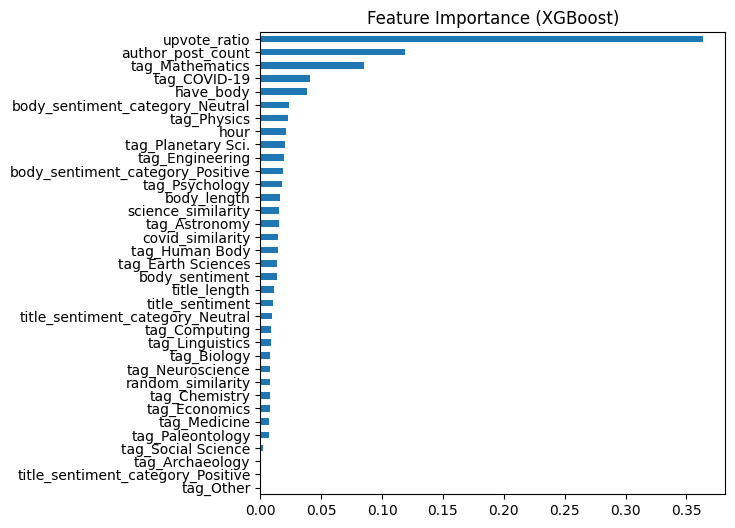

In [23]:
# Identifying the important features based on the scores
feature_importances = pd.Series(xgb_model.feature_importances_, index=updated_features)
feature_importances.sort_values(ascending=True).plot(kind='barh', figsize=(6,6))
plt.title("Feature Importance (XGBoost)")
plt.show()


Feature Importance Summary (XGBoost Model)

The most influential feature in predicting the score is upvote_ratio, followed by author_post_count, indicating that posts with higher upvote ratios and also time at which they are posting is having a high imapact on the scores, i.e., posting during prime time leads to more engagement. The tag category also plays a key role, with Physics, Mathematics, COVID-19, Engineering, Astronomy tags having significant importance. 
The posts having a body and the length of the body also have good scores. Sentiment-related features (body/title sentiment and sentiment categories) have moderate impact, while similarity-based features (science_similarity, covid_similarity, and random_similarity) contribute less. Overall, feature engineered metrics and body, topic-related features dominate the prediction model.

## Short Summary of the Analysis

This analysis focuses on predicting Reddit post scores using NLP techniques, feature engineering, and machine learning models.  

Key Findings:
- Text Processing: TF-IDF vectorization was applied to extract important keywords from titles and bodies.  
- Feature Engineering: Created features such as title length, body length, sentiment, posting time, author activity, and text similarity scores.  
- Statistical Analysis: ANOVA tests showed that some similarity scores (e.g., science_similarity) significantly impact post scores.  
- Modeling: A Random Forest Regressor was trained on selected features.Later moved to complex models Random Forest and XGBoost Regressor.
- Evaluation: The model achieved a MAE: 0.85, RMSE: 1.40, R²: 0.85 (85% variace of score is explained), with cosine similarity features outperforming binary features.  

Insights:
- Posts with scientific relevance (e.g., “supermassive black holes”) tend to receive higher scores.  
- Posting time and author activity also influence post popularity.  
- Further improvements could include adding deep learning models  to further understand/improve the predictions and PCA on frequent words, topic modeling for better text representation.  

Thank you so much for giving me the opportunity and taking the time to go through the analysis.

- Sravya